# Find P(S|chord)

In [156]:
import midi_parser as mp
import numpy as np
import importlib
import matplotlib.pyplot as plt

importlib.reload(mp)
# import pathlib as pl
# import os
# import matplotlib.pyplot as plt
# import glob

<module 'midi_parser' from 'c:\\Users\\madel\\OneDrive\\Documents\\School\\dsp\\SATB-Harmonization\\midi_parser.py'>

In [26]:
chord_to_idx = mp.getRootToIdxDict()

In [99]:
import glob
indir = "insert_path_here"
dir = f"{indir}/*"
filepaths = glob.glob(dir)

In [150]:
# metadata has form [tempo, PPQ, length_ticks, (numerator, denominator)]
midi_path='mix'
([S, A, T, B], _metadata) = mp.unpack_midi(midi_path) # get piano rolls for S, A, T, and B parts
roll = S + A + T + B # get combined piano roll
chord_roll, S = mp.get_chord_roll_and_S(midi_path)
print(np.shape(chord_roll))
print(np.shape(S))


(21, 128)
(128, 128)


In [ ]:
def getChordToS(midi_filename):
# TODO: adjust for multiple files within the path
    """
    Construct pdf for soprano line given chord
    Inputs:
        - midi_filename: file specifying midi of interest
    Outputs:
        - chord_to_s: a (numNotes) x (numChords) matrix, each entry specifying P(S|C)
        - prevchord_to_s: also (numNotes) x (numChords), but P(S|C_t-1)
    """
    # C = chord roll
    # S = soprano line piano roll
    C, S = mp.get_chord_roll_and_S(midi_filename)
    sampDur = len(C[0])
    numChords = len(C)
    numNotes = len(S[0])

    chord_to_s = np.zeros((numNotes, numChords), dtype=float)
    prevchord_to_s = np.zeros((numNotes, numChords), dtype=float)

    output = [chord_to_s, prevchord_to_s]
    for i in range(len(output)):
        transmat = output[i]
        # Get P(S|chord)
        for samp in range(i, sampDur):
            samp_notes = S[:,samp]
            samp_chords = C[:, samp-i] # if i=1, get previous sample chord
            transmat = np.add(transmat, np.outer(samp_notes, samp_chords), dtype=float)
        # chord_to_s = np.matmul(np.transpose(S), np.transpose(C))
        
        # Get P(S|chord_t-1)
        norm = np.sum(transmat, axis=0)
        norm_mat = 0.000001*np.ones(np.shape(transmat))
        norm_mat = np.add(norm_mat, (np.matlib.repmat(norm, len(transmat), 1)))
        output[i] = transmat/norm_mat
    # print(np.sum(chord_to_s, axis=0)) # each chord (of 21 options) adds up to probability 1 or 0
    return output

P(S|chord) is different from P(S|prevchord): True
total matching elements: 2664
total elements: 2688
total distinct elements: 24


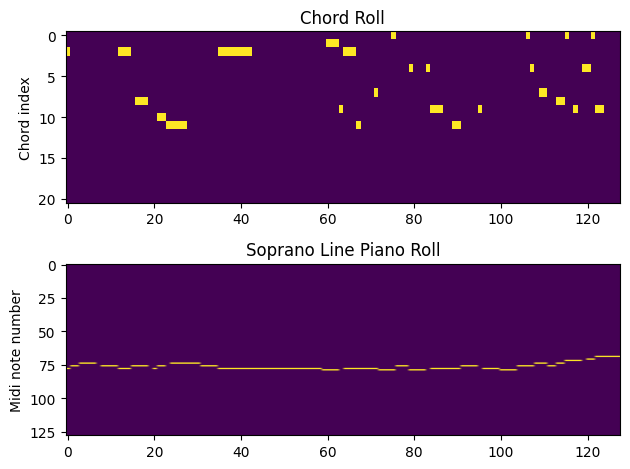

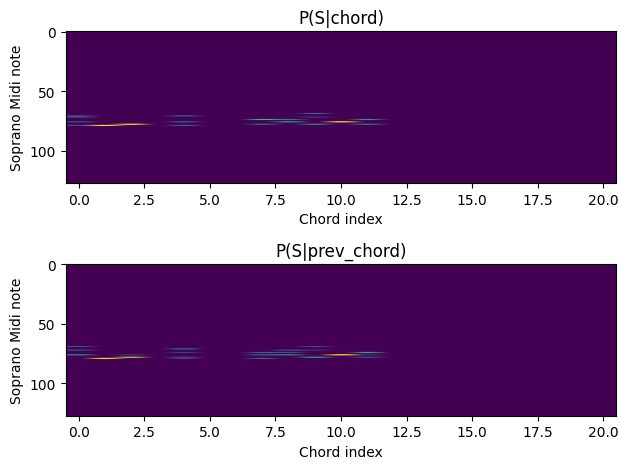

In [273]:
[chord_to_s, prevchord_to_s] = getChordToS('mix')

plt.figure(1)
plt.subplot(211)
plt.title("Chord Roll")
plt.ylabel("Chord index")
plt.imshow(chord_roll, aspect='auto')
plt.subplot(212)
plt.title("Soprano Line Piano Roll")
plt.ylabel("Midi note number")
plt.imshow(S, aspect='auto')
plt.tight_layout()

plt.figure(2)
plt.subplot(211)
plt.title("P(S|chord)")
plt.ylabel("Soprano Midi note")
plt.xlabel("Chord index")
plt.imshow(chord_to_s, aspect='auto')
plt.subplot(212)
plt.title("P(S|prev_chord)")
plt.ylabel("Soprano Midi note")
plt.xlabel("Chord index")
plt.imshow(prevchord_to_s, aspect='auto')
plt.tight_layout()


matching_elems = np.sum(np.isclose(prevchord_to_s, chord_to_s))
total_elems = np.shape(chord_to_s)[0]*np.shape(chord_to_s)[1]
print(f"P(S|chord) is different from P(S|prevchord): {not(matching_elems == total_elems)}")
print(f"total matching elements: {matching_elems}")
print(f"total elements: {total_elems}")
print(f"total distinct elements: {np.abs(total_elems - matching_elems)}")
